In [9]:
import pandas as pd
import numpy as np

from google.colab import drive
data = pd.read_csv('/content/sample_data/train.csv')
test_data = pd.read_csv('/content/sample_data/test.csv')
data.head()


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091


In [10]:
# обработка признаков

data = data.dropna()
from sklearn.preprocessing import LabelEncoder

# Создание экземпляра LabelEncoder
le = LabelEncoder()

# Обработка категориальных признаков в тренировочных данных
for column in data.drop(['ApplicationDate'], axis=1).columns:
    if data[column].dtype == 'object':
        data.loc[:, column] = le.fit_transform(data[column])  # Используем loc для изменения данных

# Удаление столбца RiskScore
data = data.drop('RiskScore', axis=1)

# Определение признаков для обучения
to_drop = ['ApplicationDate', 'AnnualIncome', 'Experience', 'InterestRate', 'CreditScore', 'TotalAssets', 'LoanAmount', 'LoanApproved']
x_train = data.drop(to_drop, axis=1)

# Проверка на пропущенные значения
print(data.isnull().sum())

# То же самое для тестовых данных
for column in test_data.drop(['ApplicationDate'], axis=1).columns:
    if test_data[column].dtype == 'object':
        test_data.loc[:, column] = le.fit_transform(test_data[column])  # Используем loc

# Определение тестовых признаков
to_drop_test = ['ApplicationDate', 'ID', 'AnnualIncome', 'Experience', 'InterestRate', 'CreditScore', 'TotalAssets', 'LoanAmount', 'LoanApproved']
y_test = test_data['LoanApproved']
x_test = test_data.drop(to_drop_test, axis=1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
EmploymentStatus              0
EducationLevel                0
Experience                    0
NetWorth                      0
BaseInterestRate              0
Interest

In [11]:
y_train = data['LoanApproved']

In [12]:
print(data.isnull().sum())
print(test_data.isnull().sum())

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
EmploymentStatus              0
EducationLevel                0
Experience                    0
NetWorth                      0
BaseInterestRate              0
Interest

In [13]:
class LinearClass_LogisticReg:
    def __init__(self, type_='linear_cl', learning_rate=0.01, iterations=1000):
        self.type_ = type_
        self.learning_rate = learning_rate
        self.iterations = iterations

    def fit(self, features, labels):
        num_samples, num_features = features.shape
        self.coefficients = np.zeros(num_features)
        self.intercept = 0.0

        for _ in range(self.iterations):
            linear_combination = np.dot(features, self.coefficients) + self.intercept

            if self.type_ == 'linear_cl':
                predictions = self._activation_function(linear_combination)
            elif self.type_ == 'logistic_reg':
                predictions = self._sigmoid(linear_combination)

            error = predictions - labels
            gradient_coeff = (1 / num_samples) * np.dot(features.T, error)
            gradient_intercept = (1 / num_samples) * np.sum(error)

            self.coefficients -= self.learning_rate * gradient_coeff
            self.intercept -= self.learning_rate * gradient_intercept

    def predict(self, features):
        linear_combination = np.dot(features, self.coefficients) + self.intercept

        if self.type_ == 'linear_cl':
            return self._activation_function(linear_combination)
        elif self.type_ == 'logistic_reg':
            prob = self._sigmoid(linear_combination)
            return np.where(prob >= 0.5, 1, 0)

    def _activation_function(self, x):
        return (x >= 0).astype(int)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))



In [14]:
!pip install catboost

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

results = []
logistic_model = LogisticRegression()
logistic_model.fit(x_train, y_train)
predictions_logistic = logistic_model.predict(x_test)
results.append(('Logistic Regression', predictions_logistic))

svc_model = SVC()
svc_model.fit(x_train, y_train)
predictions_svc = svc_model.predict(x_test)
results.append(('SVM', predictions_svc))

decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(x_train, y_train)
predictions_decision_tree = decision_tree_model.predict(x_test)
results.append(('Decision Tree', predictions_decision_tree))

random_forest_model = RandomForestClassifier()
random_forest_model.fit(x_train, y_train)
predictions_random_forest = random_forest_model.predict(x_test)
results.append(('Random Forest', predictions_random_forest))

gradient_boosting_model = GradientBoostingClassifier()
gradient_boosting_model.fit(x_train, y_train)
predictions_gradient_boosting = gradient_boosting_model.predict(x_test)
results.append(('Gradient Boosting', predictions_gradient_boosting))

lightgbm_model = LGBMClassifier()
lightgbm_model.fit(x_train, y_train)
predictions_lightgbm = lightgbm_model.predict(x_test)
results.append(('LightGBM', predictions_lightgbm))

xgboost_model = XGBClassifier()
xgboost_model.fit(x_train, y_train)
predictions_xgboost = xgboost_model.predict(x_test)
results.append(('XGBoost', predictions_xgboost))

catboost_model = CatBoostClassifier(verbose=0)
catboost_model.fit(x_train, y_train)
predictions_catboost = catboost_model.predict(x_test)
results.append(('CatBoost', predictions_catboost))

custom_linear_model = LinearClass_LogisticReg(type_='linear_cl', learning_rate=0.01, iterations=1000)
custom_linear_model.fit(x_train, y_train)
predictions_custom_linear = custom_linear_model.predict(x_test)
results.append(('Linear Classifier', predictions_custom_linear))

custom_logistic_model = LinearClass_LogisticReg(type_='logistic_reg', learning_rate=0.01, iterations=1000)
custom_logistic_model.fit(x_train, y_train)
predictions_custom_logistic = custom_logistic_model.predict(x_test)
results.append(('Logistic Regression', predictions_custom_logistic))


[LightGBM] [Info] Number of positive: 5116, number of negative: 4870
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3275
[LightGBM] [Info] Number of data points in the train set: 9986, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512317 -> initscore=0.049279
[LightGBM] [Info] Start training from score 0.049279


Model: Logistic Regression
Accuracy: 0.93
Precision: 0.93
Recall: 0.93
F1 Score: 0.93


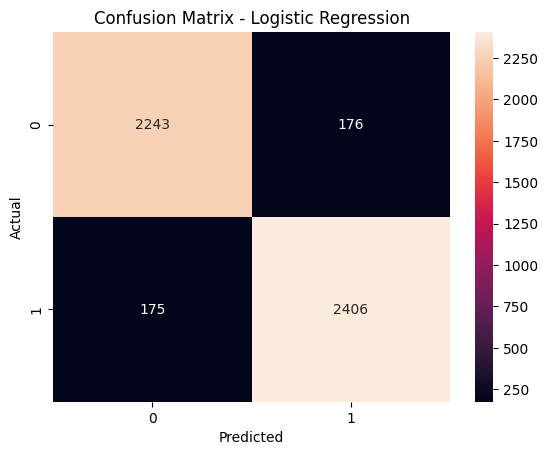

Model: SVM
Accuracy: 0.93
Precision: 0.93
Recall: 0.93
F1 Score: 0.93


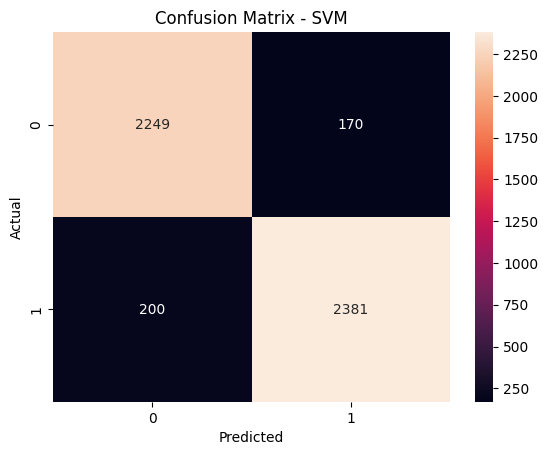

Model: Decision Tree
Accuracy: 0.89
Precision: 0.89
Recall: 0.89
F1 Score: 0.89


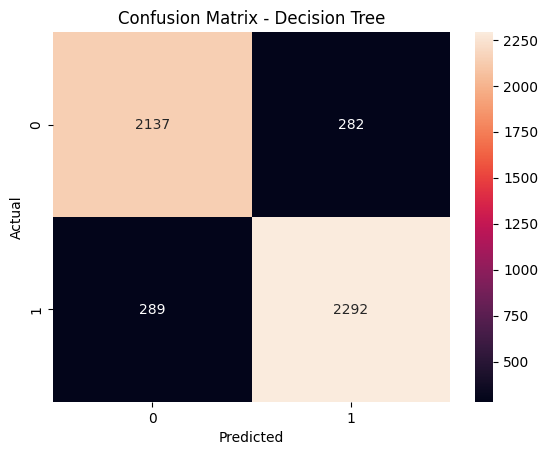

Model: Random Forest
Accuracy: 0.92
Precision: 0.92
Recall: 0.92
F1 Score: 0.92


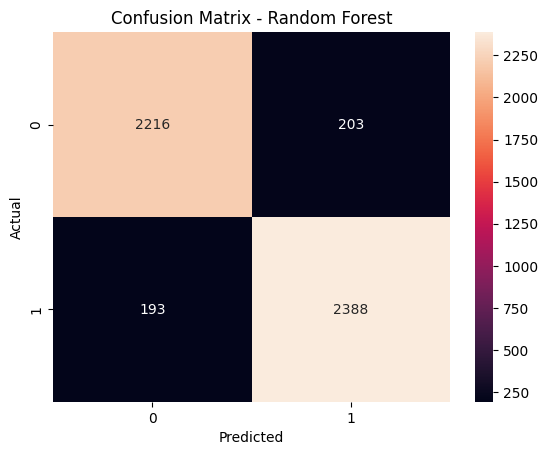

Model: Gradient Boosting
Accuracy: 0.93
Precision: 0.93
Recall: 0.93
F1 Score: 0.93


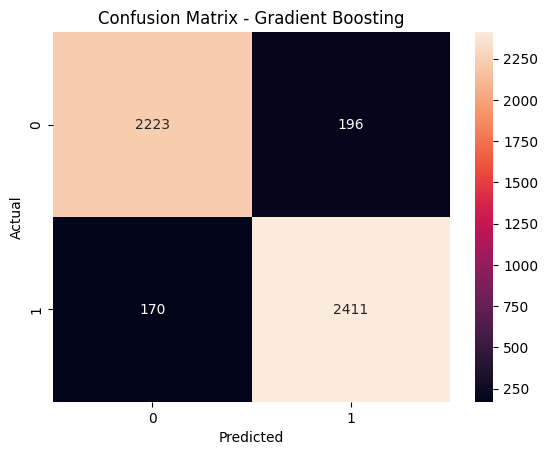

Model: LightGBM
Accuracy: 0.93
Precision: 0.93
Recall: 0.93
F1 Score: 0.93


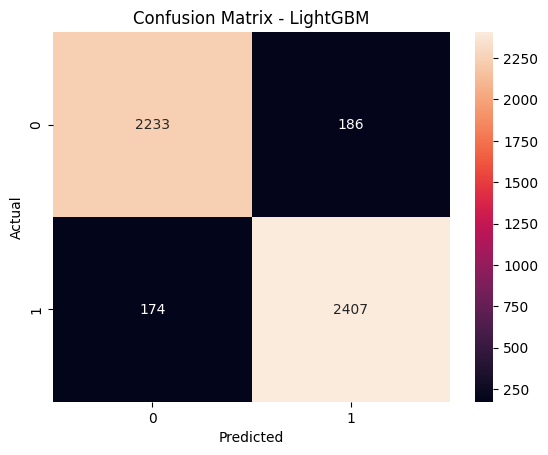

Model: XGBoost
Accuracy: 0.92
Precision: 0.92
Recall: 0.92
F1 Score: 0.92


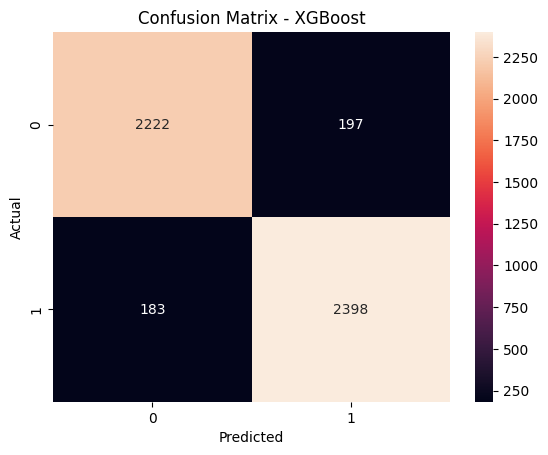

Model: CatBoost
Accuracy: 0.93
Precision: 0.93
Recall: 0.93
F1 Score: 0.93


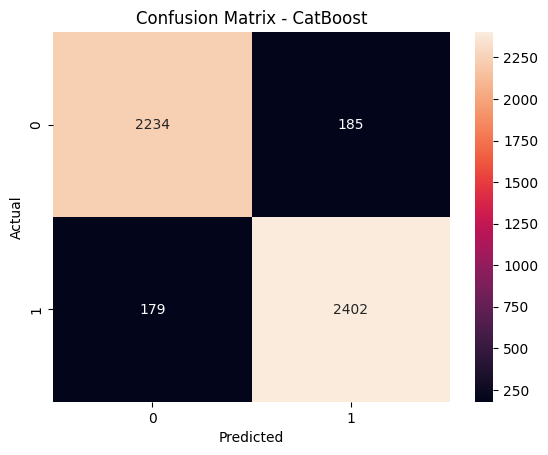

Model: Linear Classifier
Accuracy: 0.90
Precision: 0.91
Recall: 0.90
F1 Score: 0.90


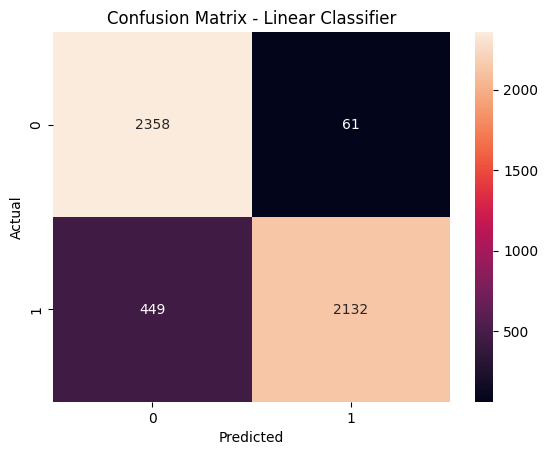

Model: Logistic Regression
Accuracy: 0.91
Precision: 0.91
Recall: 0.91
F1 Score: 0.91


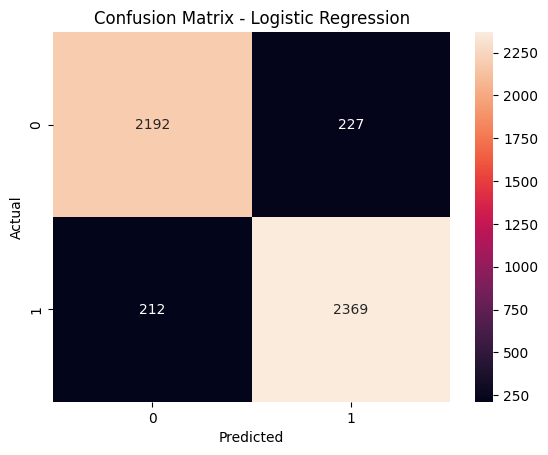

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def models_res(y_test, y_pred, name_):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Model: {name_}")
    print(f"Accuracy: {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall: {rec:.2f}")
    print(f"F1 Score: {f1:.2f}")

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='rocket')
    plt.title(f'Confusion Matrix - {name_}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Цикл для оценки каждой модели
for name_, y_pred in results:
    models_res(y_test, y_pred, name_)

Вывод: было представлено решение задачи классификации, в результате которого получены такие данные:
 Logistic Regression:
Accuracy: 0.91, Precision: 0.91, Recall: 0.91, F1 Score: 0.91; Model: Linear Classifier:
Accuracy: 0.90,
Precision: 0.91,
Recall: 0.90,
F1 Score: 0.90


Модели относительно хорошо предсказывают результат, однако все же работают не так качественно, как модели из библиотеки sklearn. Линейный классификатор не совсем точно определяет принадлежность истинного класса к нему же, получается, что некоторые значения из класса "1" предсказываются как "0".

Вероятно, готовые реализации работают лучше благодаря применяемым оптимизациям, реализованным в библиотеке sklearn. Также можно выявить некоторые другие закономерности. Дерево решений работает хуже, чем, например, случайный лес, поскольку сама по себе первая модель работает хуже из-за вероятности переобучения, да и их предсказательная точность часто ниже, чем у более сложных моделей, таких как ансамбли, которые используют множество деревьев (например, случайные леса).